# Example 5.0 - Use catXAS to Perform a PCA Analysis on XAS Spectra
## Authors: Anika Jalil (UCSB), Adam S. Hoffman (SLAC), Jason Chalmers (UCSB), Emmanuel (Noel) Hiennadi (Va Tech)
    Note: Code was streamlined using Claude Sonnet 4.5

In [1]:
# File/OS Handling:
import os

# Data Handling:
import pandas as pd

# CatXAS:
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp
import pca

# Step 1. Load Spectra Data into a Pandas DataFrame

In [2]:
# Where is the Data Stored
XAS_dir_name = os.path.join(pwd, 'sample results')

# What is the name of the file (include extension)
fname = r'SnO2_TPR_NormXANES.csv'

# What is the separator?

sep = ',' # common options: '\t' ',' '\s'

# Energy Column?

e_col = 0

# Has Heder?

header = None # alternate option is to specify the row number of the header [default = 0]
header_lines = 1 # number of lines to skip for a long header

XAS_df = pd.read_csv(os.path.join(XAS_dir_name, fname), sep = sep, index_col = e_col, header = header, skiprows = header_lines)

# Step 2. Define Enery and Spectra Range to Perform PCA Analysis On

In [3]:
widgets_dict = pca.select_spectral_range(XAS_df, 
                     xlabel='Energy (eV)', 
                     ylabel='Absorption',
                     figsize=(10, 7))

interactive(children=(Dropdown(description='Energy Min:', options=(np.float64(29050.0), np.float64(29050.25), …

In [4]:
# Create a copy of the XAS data for PCA analysis:
df_pca = XAS_df.loc[widgets_dict['e_min'].value:widgets_dict['e_max'].value].iloc[:,widgets_dict['s_min'].value:widgets_dict['s_max'].value].copy()

# Step 3a. Perform PCA/Truncated SVD

## Arguments:
    mean_center - if True - uses sklearn PCA analysis, if False - used sklearn TruncatedSVD analysis 
    n_components - strictly the number of spectra in the model, Default = None. NO NEED TO MODIFY

In [5]:
# With mean-centering (standard PCA)
pca_results = pca.perform_pca_analysis(df_pca, mean_center=True, n_components=None)

# Without mean-centering (using TruncatedSVD)
svd_results = pca.perform_pca_analysis(df_pca, mean_center=False, n_components=None)

Input DataFrame shape: (1601, 49)
Number of energy points (features): 1601
Number of spectra (samples): 49
Transposed shape for sklearn: (49, 1601)
(rows=spectra, columns=energy points)

Using PCA with mean-centering...

Analysis Results:
Mean-centering: True
Number of components extracted: 49
Size of Eigenspectra array: (49, 1601) (components × energy_points)
Length of CVE list: 49
Size of Score array: (49, 49) (spectra × components)
Size of Covariance Matrix: (1601, 1601)
Energy range of Spectra [eV]: 29050.0-29450.0
Input DataFrame shape: (1601, 49)
Number of energy points (features): 1601
Number of spectra (samples): 49
Transposed shape for sklearn: (49, 1601)
(rows=spectra, columns=energy points)

Using SVD without mean-centering...

Analysis Results:
Mean-centering: False
Number of components extracted: 49
Size of Eigenspectra array: (49, 1601) (components × energy_points)
Length of CVE list: 49
Size of Score array: (49, 49) (spectra × components)
Size of Covariance Matrix: (1601

# Step 3b. Visualize Scree and Eigenspectra results + Score Plot to show Trajectories

Knee detected at component 3 (CVE = 0.9987)
Suggested number of components: 2 (CVE = 0.9985)


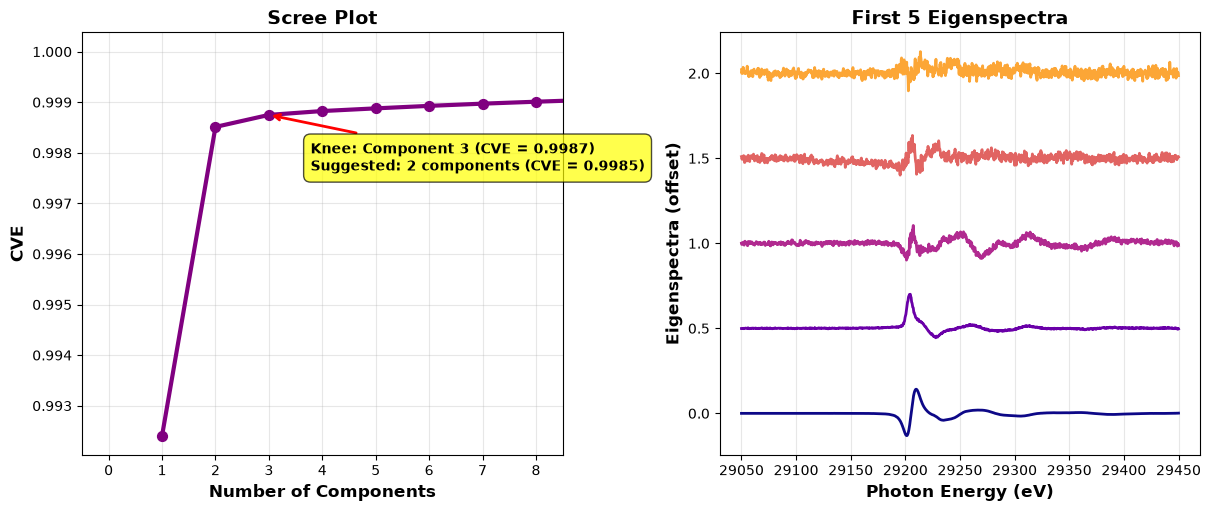

In [6]:
# PCA Example
_ = pca.plot_pca_results(pca_results, n_eigenspectra=5, spacing=0.5, figsize=(12, 5))

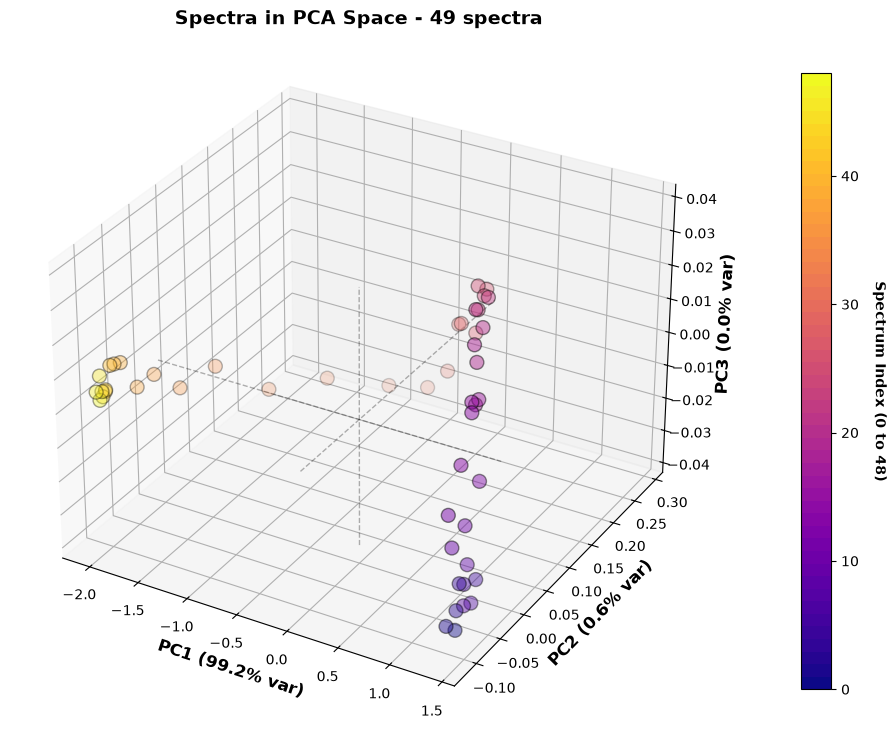


Plot Information:
Total spectra: 49
Each point represents one spectrum
Colors: gradient from spectrum 0 to spectrum 48
Colormap: plasma
Position: determined by projection onto first 3 PCs


In [7]:
_ = pca.plot_pca_scores_3d(pca_results, df_pca, colormap='plasma')

Knee detected at component 2 (CVE = 0.9926)
Suggested number of components: 1 (CVE = 0.0008)


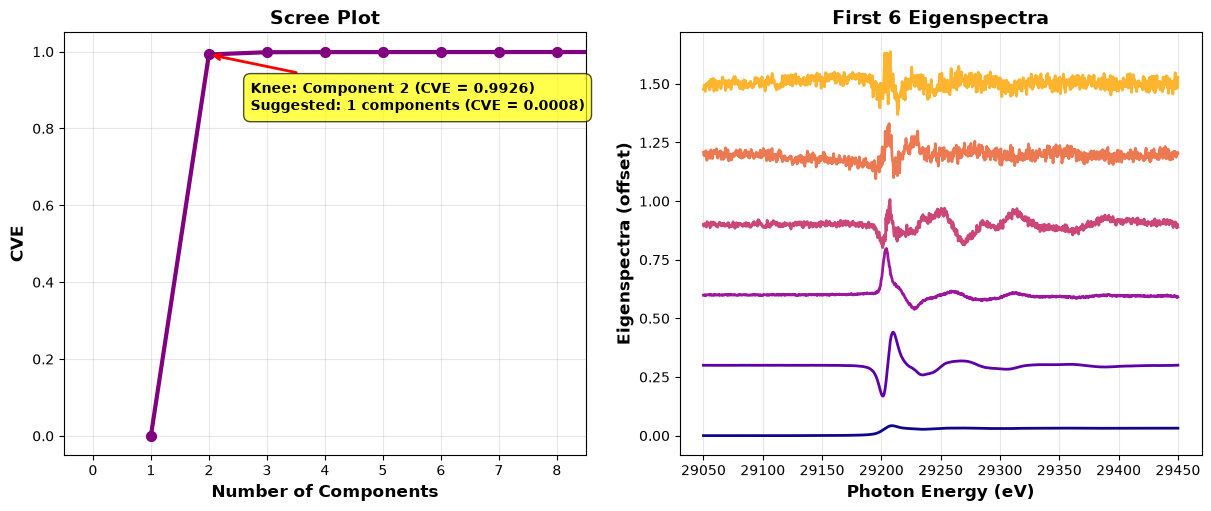

In [8]:
# TruncatedSVD example
_ = pca.plot_pca_results(svd_results, n_eigenspectra=6, spacing=0.3, figsize=(12, 5))

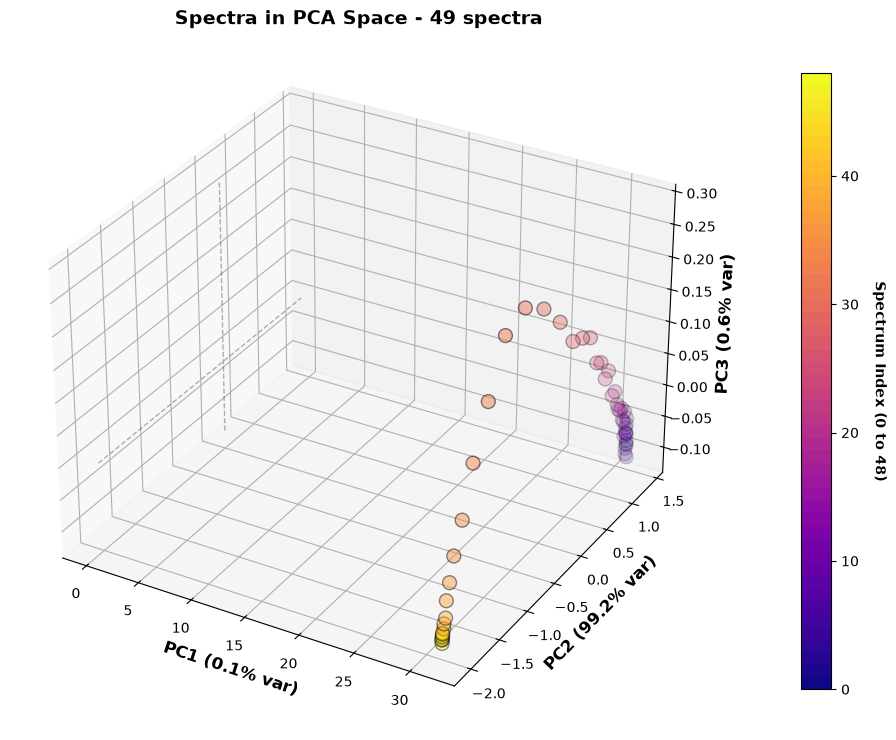


Plot Information:
Total spectra: 49
Each point represents one spectrum
Colors: gradient from spectrum 0 to spectrum 48
Colormap: plasma
Position: determined by projection onto first 3 PCs


In [9]:
_ = pca.plot_pca_scores_3d(svd_results, df_pca, colormap='plasma')

# Step 3c. Reconstruct a Spectra with a Set number of Components

In [10]:
# PCA Example
_ = pca.interactive_pca_reconstruction(pca_results, df_pca)

In [11]:
# TruncatedSVD Example
_ = pca.interactive_pca_reconstruction(svd_results, df_pca)

# Step 3d. Compare PCA vs. TruncatedSVD

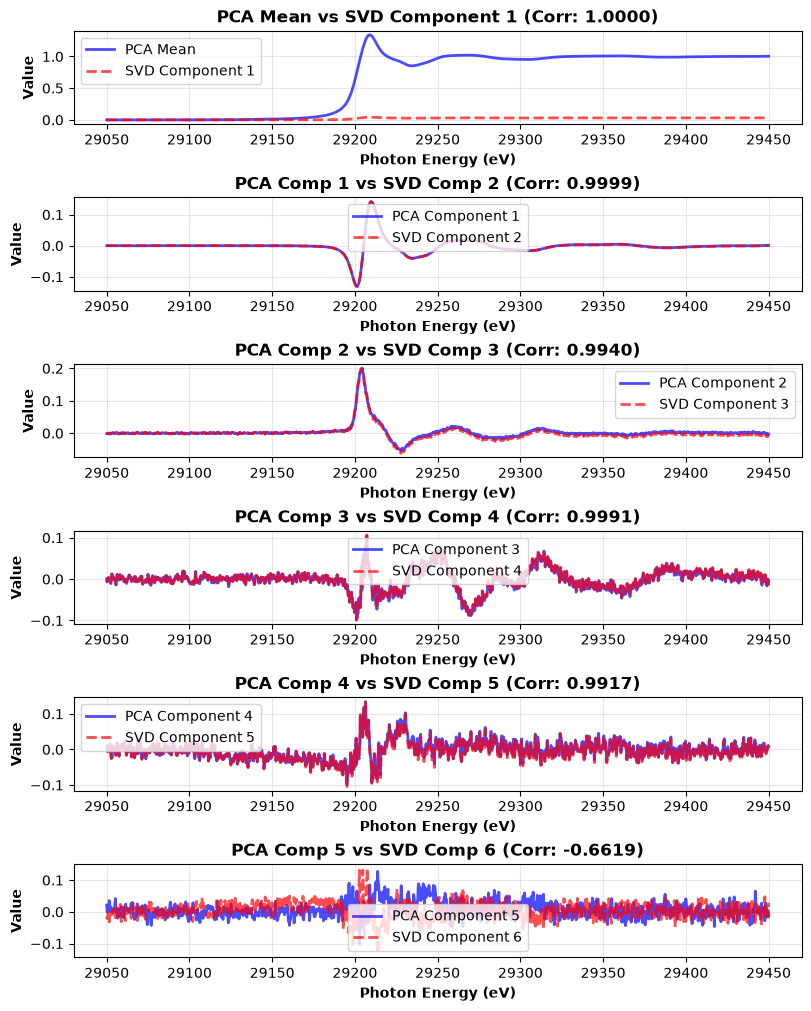

Correlation Coefficients:
  PCA Mean vs SVD Component 1: 1.000000
  PCA Comp 1 vs SVD Comp 2: 0.999905
  PCA Comp 2 vs SVD Comp 3: 0.994049
  PCA Comp 3 vs SVD Comp 4: 0.999147
  PCA Comp 4 vs SVD Comp 5: 0.991738
  PCA Comp 5 vs SVD Comp 6: -0.661897


In [12]:
comparison = pca.compare_pca_svd(pca_results, svd_results, df_pca, n_components=5,figsize=(8,10))

# Step 4. Save PCA/Truncated SVD Results

In [13]:
output_dir = os.path.join(pwd, 'sample results')

In [14]:
# PCA Example

base_name  = r'SnO2_TPR_PCA'

# Save results
saved_files = pca.save_pca_results(
    pca_results=pca_results,
    save_dir=output_dir,
    base_name=base_name
)

Saved eigenspectra (with mean) to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_PCA_eigenspectra_with_mean.csv
Saved CVE to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_PCA_CVE.csv
Saved scores to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_PCA_scores.csv

Summary:
  Mean-centered: True
  Number of components: 49
  Number of spectra: 49
  All files saved to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results


In [15]:
# TruncatedSVD Example

base_name  = r'SnO2_TPR_SVD'

# Save results
saved_files = pca.save_pca_results(
    pca_results=pca_results,
    save_dir=output_dir,
    base_name=base_name
)

Saved eigenspectra (with mean) to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_SVD_eigenspectra_with_mean.csv
Saved CVE to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_SVD_CVE.csv
Saved scores to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_SVD_scores.csv

Summary:
  Mean-centered: True
  Number of components: 49
  Number of spectra: 49
  All files saved to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results
